In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
benjaminkz_places365_path = kagglehub.dataset_download('benjaminkz/places365')

print('Data source import complete.')


Download already complete (25260734874 bytes).
Extracting files...
Data source import complete.


In [ ]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
train_dir = benjaminkz_places365_path + '/train'
val_dir = benjaminkz_places365_path + '/val'

Total scene categories: 365


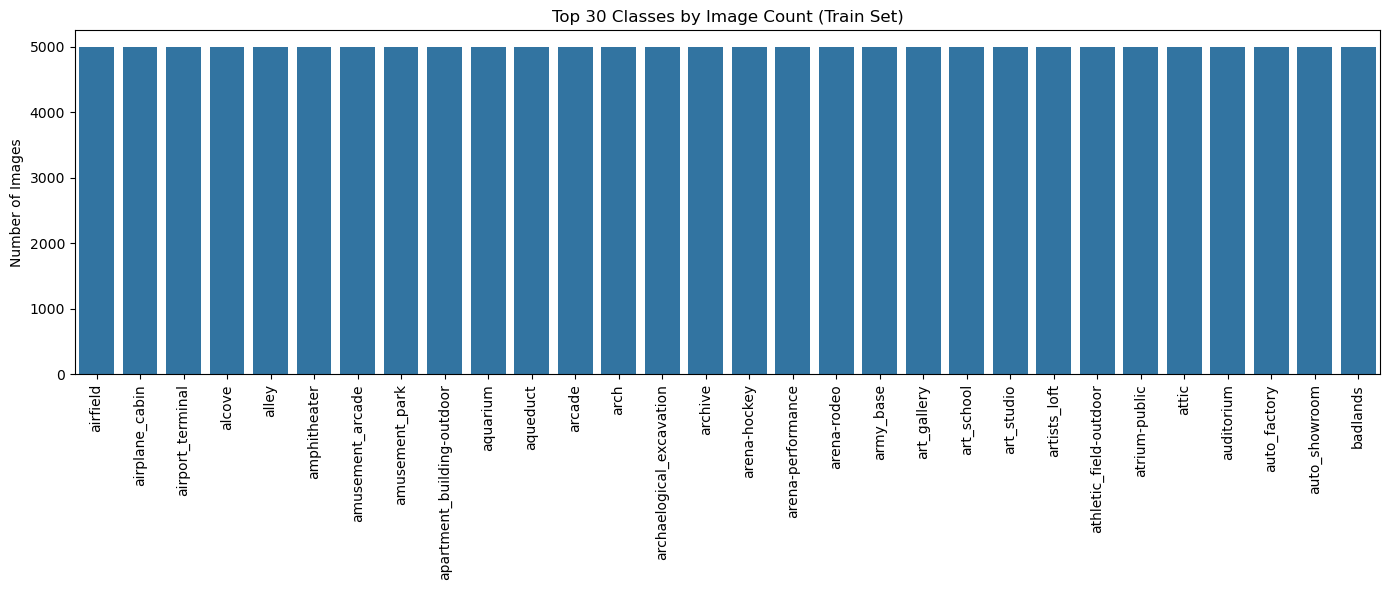

Total training images: 1803460
Image dimension stats (WxH):
Mean: [256. 256.]
Median: [256. 256.]
Min: [256 256]
Max: [256 256]


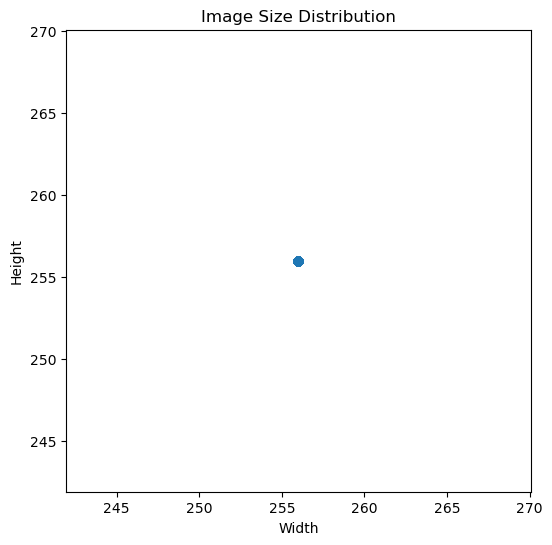

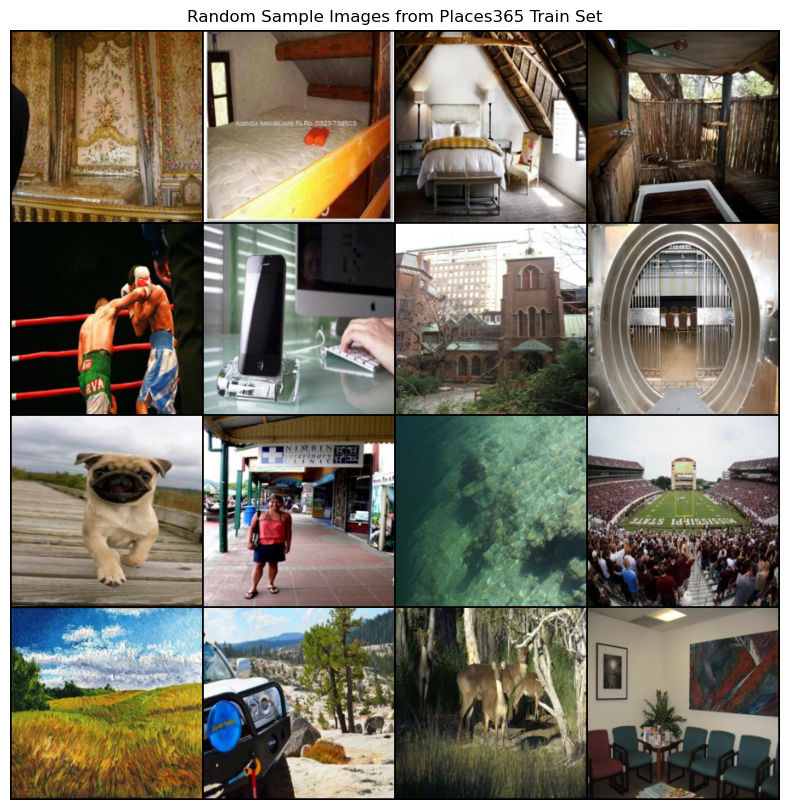

Sample Labels:
['bedchamber', 'berth', 'attic', 'shower', 'boxing_ring', 'home_office', 'synagogue-outdoor', 'bank_vault', 'boardwalk', 'arcade', 'underwater-ocean_deep', 'football_field', 'field-cultivated', 'tundra', 'forest-broadleaf', 'waiting_room']


In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from PIL import Image
from collections import Counter
import seaborn as sns

# Define path


# Optional: limit for faster EDA
sample_limit = 10000

# 1. List class names
class_names = sorted(os.listdir(train_dir))
print(f"Total scene categories: {len(class_names)}")

# 2. Count images per class
class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names}
sorted_counts = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True))

# Plot class distribution
plt.figure(figsize=(14, 6))
sns.barplot(x=list(sorted_counts.keys())[:30], y=list(sorted_counts.values())[:30])
plt.xticks(rotation=90)
plt.title("Top 30 Classes by Image Count (Train Set)")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# 3. Count total images
total_images = sum(class_counts.values())
print(f"Total training images: {total_images}")

# 4. Analyze image dimensions
img_dims = []
for i, cls in enumerate(class_names):
    if i * 10 > sample_limit:
        break
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path)[:10]:
        img_path = os.path.join(cls_path, img_name)
        try:
            with Image.open(img_path) as img:
                img_dims.append(img.size)  # (width, height)
        except:
            continue  # skip corrupt image

# Convert to numpy and plot
img_dims = np.array(img_dims)
print("Image dimension stats (WxH):")
print(f"Mean: {np.mean(img_dims, axis=0)}")
print(f"Median: {np.median(img_dims, axis=0)}")
print(f"Min: {np.min(img_dims, axis=0)}")
print(f"Max: {np.max(img_dims, axis=0)}")

plt.figure(figsize=(6, 6))
plt.scatter(img_dims[:, 0], img_dims[:, 1], alpha=0.5)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Image Size Distribution')
plt.show()

# 5. Visualize random samples
import random
from torchvision.utils import make_grid
from torchvision.transforms import ToTensor

sample_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    ToTensor()
])

sample_imgs = []
sample_labels = []

for _ in range(16):
    cls = random.choice(class_names)
    img_path = os.path.join(train_dir, cls, random.choice(os.listdir(os.path.join(train_dir, cls))))
    try:
        img = Image.open(img_path).convert('RGB')
        sample_imgs.append(sample_transform(img))
        sample_labels.append(cls)
    except:
        continue

# Plot grid
grid_img = make_grid(sample_imgs, nrow=4, normalize=True)
plt.figure(figsize=(10, 10))
plt.imshow(grid_img.permute(1, 2, 0))
plt.axis('off')
plt.title("Random Sample Images from Places365 Train Set")
plt.show()

print("Sample Labels:")
print(sample_labels)


In [4]:
from torch.utils.data import Subset
import numpy as np

def get_subset_loaders(train_dir, val_dir, batch_size=64, subset_fraction=0.01):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    train_dataset = datasets.ImageFolder(train_dir, transform=transform)
    val_dataset = datasets.ImageFolder(val_dir, transform=transform)

    # Randomly select subset indices
    train_subset_indices = np.random.choice(len(train_dataset), int(len(train_dataset) * subset_fraction), replace=False)
    val_subset_indices = np.random.choice(len(val_dataset), int(len(val_dataset) * subset_fraction), replace=False)

    train_subset = Subset(train_dataset, train_subset_indices)
    val_subset = Subset(val_dataset, val_subset_indices)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader


In [11]:
def hyperparameter_search(train_dir, val_dir, device):
    subset_fraction = 0.005
    learning_rates = [0.001, 0.0005]
    batch_sizes = [64, 128, 256]
    weight_decays = [0, 1e-4]

    results = []

    for lr in learning_rates:
        for batch_size in batch_sizes:
            for wd in weight_decays:
                print(f'\n[SEARCH] lr={lr}, batch_size={batch_size}, weight_decay={wd}')
                train_loader, val_loader = get_subset_loaders(train_dir, val_dir, batch_size=batch_size, subset_fraction=subset_fraction)
                model = LightResNet(num_classes=365).to(device)

                optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
                criterion = nn.CrossEntropyLoss()

                # Train for 1 epoch for speed
                model.train()
                for inputs, targets in train_loader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                    loss.backward()
                    optimizer.step()

                # Evaluate
                model.eval()
                correct, total = 0, 0
                with torch.no_grad():
                    for inputs, targets in val_loader:
                        inputs, targets = inputs.to(device), targets.to(device)
                        outputs = model(inputs)
                        _, predicted = torch.max(outputs, 1)
                        total += targets.size(0)
                        correct += (predicted == targets).sum().item()
                acc = 100 * correct / total
                print(f'[RESULT] Val Accuracy: {acc:.2f}%')

                results.append((lr, batch_size, wd, acc))

    # Sort results by best accuracy
    results.sort(key=lambda x: x[3], reverse=True)
    print('\n[SUMMARY] Top Configs:')
    for r in results[:5]:
        print(f'LR: {r[0]}, Batch Size: {r[1]}, WD: {r[2]} → Acc: {r[3]:.2f}%')


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import tqdm
import os

# ---------- 1. Lightweight ResNet ----------
class LightResNet(nn.Module):
    def __init__(self, num_classes=365):
        super(LightResNet, self).__init__()
        resnet = torch.hub.load('pytorch/vision', 'resnet18', pretrained=False)
        resnet.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        resnet.bn1 = nn.BatchNorm2d(64)
        resnet.layer4 = nn.Identity()
        resnet.fc = nn.Linear(256, num_classes)
        self.model = resnet

    def forward(self, x):
        return self.model(x)

# ---------- 2. Data Loading ----------
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import random

def get_data_loaders(train_dir, val_dir, batch_size=64, fraction=0.1):
    transform = transforms.Compose([
        # transforms.Resize((224, 224)),
        transforms.Resize((160, 160)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Load full datasets
    train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
    print("Fetched train dataset")
    val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)
    print("Fetched validation dataset")

    # Get tiny fraction of dataset
    def get_subset(dataset, fraction):
        num_samples = max(1, int(len(dataset) * fraction))  # At least 1 sample
        indices = random.sample(range(len(dataset)), num_samples)
        return Subset(dataset, indices)

    train_subset = get_subset(train_dataset, fraction)
    val_subset = get_subset(val_dataset, fraction)

    # Create loaders
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader


# ---------- 3. Validation ----------
def validate_model(model, val_loader, device):
    model.eval()
    correct, total = 0, 0
    val_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    acc = 100 * correct / total
    avg_loss = val_loss / len(val_loader)
    print(f'[VALIDATION] Loss: {avg_loss:.4f} | Accuracy: {acc:.2f}%\n')

# ---------- 4. Training ----------
def train_model(model, train_loader, val_loader, device, epochs=3, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0
        start_time = time.time()

        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

            # Debug logs
            if batch_idx % 100 == 0:
                print(f'[DEBUG] Epoch {epoch+1}/{epochs} | Batch {batch_idx} | Loss: {loss.item():.4f}')

        acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)
        print(f'\nEpoch {epoch+1} completed in {time.time() - start_time:.2f}s')
        print(f'[TRAINING] Loss: {avg_loss:.4f} | Accuracy: {acc:.2f}%')

        print("Evaluating model")
        validate_model(model, val_loader, device)



In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LightResNet(num_classes=365)
hyperparameter_search(train_dir, val_dir, device)

Using cache found in /Users/vishali/.cache/torch/hub/pytorch_vision_main



[SEARCH] lr=0.001, batch_size=64, weight_decay=0


Using cache found in /Users/vishali/.cache/torch/hub/pytorch_vision_main


[RESULT] Val Accuracy: 0.55%

[SEARCH] lr=0.001, batch_size=64, weight_decay=0.0001


Using cache found in /Users/vishali/.cache/torch/hub/pytorch_vision_main


...

[RESULT] Val Accuracy: 1.65%

[SEARCH] lr=0.0005, batch_size=256, weight_decay=0


Using cache found in /Users/vishali/.cache/torch/hub/pytorch_vision_main


[RESULT] Val Accuracy: 1.65%

[SEARCH] lr=0.0005, batch_size=256, weight_decay=0.0001


Using cache found in /Users/vishali/.cache/torch/hub/pytorch_vision_main


[RESULT] Val Accuracy: 1.10%

[SUMMARY] Top Configs:
LR: 0.001, Batch Size: 256, WD: 0 → Acc: 2.20%
LR: 0.001, Batch Size: 128, WD: 0 → Acc: 1.65%
LR: 0.0005, Batch Size: 64, WD: 0 → Acc: 1.65%
LR: 0.0005, Batch Size: 64, WD: 0.0001 → Acc: 1.65%
LR: 0.0005, Batch Size: 128, WD: 0 → Acc: 1.65%


In [15]:
# subset size = 0.01
# ---------- 5. Main ----------
if __name__ == '__main__':

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'[INFO] Using device: {device}')
    print("loading dataloaders")
    train_loader, val_loader = get_data_loaders(train_dir, val_dir, batch_size=256)
    model = LightResNet(num_classes=365)
    print("Starting training")
    train_model(model, train_loader, val_loader, device, epochs=3, lr=0.01)


[INFO] Using device: cpu
loading dataloaders
Fetched train dataset
Fetched validation dataset
Starting training


Using cache found in /Users/vishali/.cache/torch/hub/pytorch_vision_main


[DEBUG] Epoch 1/3 | Batch 0 | Loss: 6.0070
[DEBUG] Epoch 1/3 | Batch 20 | Loss: 5.8785
[DEBUG] Epoch 1/3 | Batch 40 | Loss: 5.8394
[DEBUG] Epoch 1/3 | Batch 60 | Loss: 5.7305

Epoch 1 completed in 791.30s
[TRAINING] Loss: 5.9005 | Accuracy: 0.64%
[VALIDATION] Loss: 5.7664 | Accuracy: 1.10%

[DEBUG] Epoch 2/3 | Batch 0 | Loss: 5.6573
[DEBUG] Epoch 2/3 | Batch 20 | Loss: 5.5836
[DEBUG] Epoch 2/3 | Batch 40 | Loss: 5.5962
[DEBUG] Epoch 2/3 | Batch 60 | Loss: 5.4865

Epoch 2 completed in 922.60s
[TRAINING] Loss: 5.5796 | Accuracy: 1.31%
[VALIDATION] Loss: 5.5375 | Accuracy: 1.10%

[DEBUG] Epoch 3/3 | Batch 0 | Loss: 5.3291
[DEBUG] Epoch 3/3 | Batch 20 | Loss: 5.3799
[DEBUG] Epoch 3/3 | Batch 40 | Loss: 5.3225
[DEBUG] Epoch 3/3 | Batch 60 | Loss: 5.1582

Epoch 3 completed in 823.75s
[TRAINING] Loss: 5.3203 | Accuracy: 2.42%
[VALIDATION] Loss: 5.3435 | Accuracy: 2.19%



In [19]:
# subset size = 0.1
# ---------- 5. Main ----------
if __name__ == '__main__':

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'[INFO] Using device: {device}')
    print("loading dataloaders")
    train_loader, val_loader = get_data_loaders(train_dir, val_dir, batch_size=256)
    model = LightResNet(num_classes=365)
    print("Starting training")
    train_model(model, train_loader, val_loader, device, epochs=5, lr=0.01)

[INFO] Using device: cpu
loading dataloaders
Fetched train dataset
Fetched validation dataset
Starting training


Using cache found in /Users/vishali/.cache/torch/hub/pytorch_vision_main


[DEBUG] Epoch 1/5 | Batch 0 | Loss: 6.0270
[DEBUG] Epoch 1/5 | Batch 20 | Loss: 5.9681
[DEBUG] Epoch 1/5 | Batch 40 | Loss: 5.8900
[DEBUG] Epoch 1/5 | Batch 60 | Loss: 5.8482
[DEBUG] Epoch 1/5 | Batch 80 | Loss: 5.7618
[DEBUG] Epoch 1/5 | Batch 100 | Loss: 5.7342
[DEBUG] Epoch 1/5 | Batch 120 | Loss: 5.6215
[DEBUG] Epoch 1/5 | Batch 140 | Loss: 5.4316
[DEBUG] Epoch 1/5 | Batch 160 | Loss: 5.4883
[DEBUG] Epoch 1/5 | Batch 180 | Loss: 5.2439
[DEBUG] Epoch 1/5 | Batch 200 | Loss: 5.3040
[DEBUG] Epoch 1/5 | Batch 220 | Loss: 5.1477
[DEBUG] Epoch 1/5 | Batch 240 | Loss: 5.1978
[DEBUG] Epoch 1/5 | Batch 260 | Loss: 5.0490
[DEBUG] Epoch 1/5 | Batch 280 | Loss: 4.9709
[DEBUG] Epoch 1/5 | Batch 300 | Loss: 4.9031
[DEBUG] Epoch 1/5 | Batch 320 | Loss: 4.9500
[DEBUG] Epoch 1/5 | Batch 340 | Loss: 4.9906
[DEBUG] Epoch 1/5 | Batch 360 | Loss: 4.8883
[DEBUG] Epoch 1/5 | Batch 380 | Loss: 4.7897
[DEBUG] Epoch 1/5 | Batch 400 | Loss: 4.8982
[DEBUG] Epoch 1/5 | Batch 420 | Loss: 4.8098
[DEBUG] Epoch 1/

In [20]:
torch.save(model.state_dict(), 'lightresnet_weights.pth')
print(" Model weights saved to 'lightresnet_weights.pth'")
# current_epoch = 5
# torch.save({
#     'epoch': current_epoch,
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'loss': current_loss,
# }, 'checkpoint.pth')
# print("Full checkpoint saved to 'checkpoint.pth'")

 Model weights saved to 'lightresnet_weights.pth'


In [21]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def evaluate_and_visualize(model, val_loader, device, class_names=None, max_misclassified=5):
    model.eval()
    all_preds = []
    all_labels = []
    misclassified = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())

            # Collect misclassified examples
            for i in range(len(preds)):
                if preds[i] != targets[i]:
                    if len(misclassified) < max_misclassified:
                        misclassified.append((inputs[i].cpu(), preds[i].item(), targets[i].item()))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, xticks_rotation=90)
    plt.title("Confusion Matrix")
    plt.show()

    # Plot Misclassified Images
    if misclassified:
        print(f"\n📸 Showing {len(misclassified)} misclassified images:")
        fig, axes = plt.subplots(1, len(misclassified), figsize=(15, 5))
        for idx, (img, pred, label) in enumerate(misclassified):
            img = img.permute(1, 2, 0).numpy()  # CxHxW → HxWxC
            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # de-normalize
            img = np.clip(img, 0, 1)
            axes[idx].imshow(img)
            axes[idx].set_title(f"Pred: {class_names[pred] if class_names else pred}\nTrue: {class_names[label] if class_names else label}")
            axes[idx].axis('off')
        plt.show()


In [28]:
class Places365ValDataset(torch.utils.data.Dataset):
    def __init__(self, val_txt, root_dir, transform=None):
        self.samples = []
        self.root_dir = root_dir
        self.transform = transform
        with open(val_txt, 'r') as f:
            for line in f:
                path, label = line.strip().split()
                self.samples.append((path, int(label)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(os.path.join(self.root_dir, img_path)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


with open(benjaminkz_places365_path + '/val.txt', 'r') as f:
    class_names = [line.strip().split(' ')[0] for line in f]
    # print(class_names)

['val/field-cultivated/Places365_val_00032701.jpg', 'val/field-cultivated/Places365_val_00010661.jpg', 'val/field-cultivated/Places365_val_00004872.jpg', 'val/field-cultivated/Places365_val_00014942.jpg', 'val/field-cultivated/Places365_val_00002425.jpg', 'val/field-cultivated/Places365_val_00015796.jpg', 'val/field-cultivated/Places365_val_00008534.jpg', 'val/field-cultivated/Places365_val_00024393.jpg', 'val/field-cultivated/Places365_val_00020495.jpg', 'val/field-cultivated/Places365_val_00009061.jpg', 'val/field-cultivated/Places365_val_00029120.jpg', 'val/field-cultivated/Places365_val_00002748.jpg', 'val/field-cultivated/Places365_val_00002548.jpg', 'val/field-cultivated/Places365_val_00001829.jpg', 'val/field-cultivated/Places365_val_00022313.jpg', 'val/field-cultivated/Places365_val_00018372.jpg', 'val/field-cultivated/Places365_val_00013352.jpg', 'val/field-cultivated/Places365_val_00027604.jpg', 'val/field-cultivated/Places365_val_00002990.jpg', 'val/field-cultivated/Places36

ValueError: The number of FixedLocator locations (365), usually from a call to set_ticks, does not match the number of labels (36500).

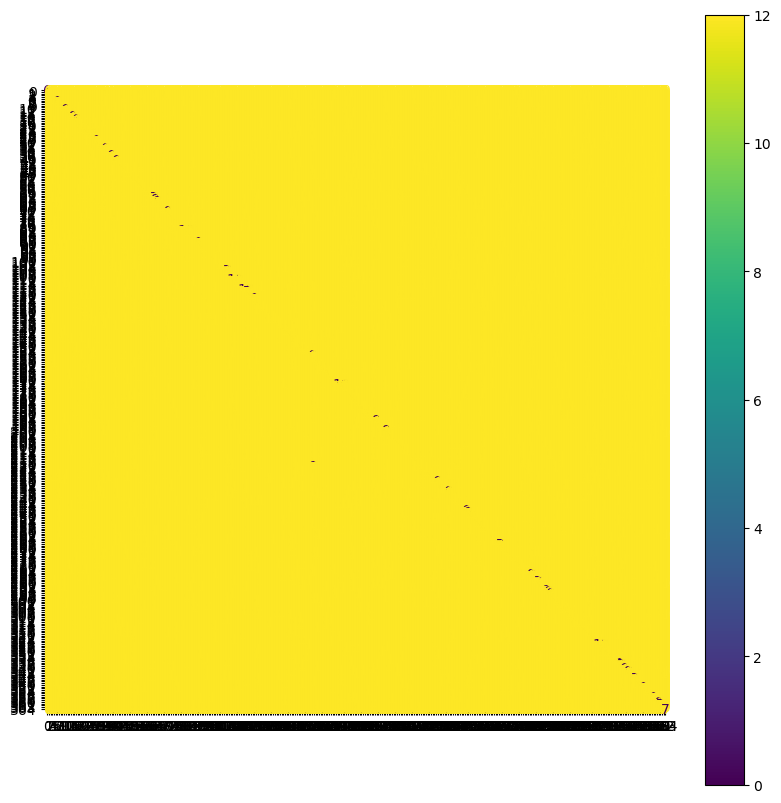

In [29]:
evaluate_and_visualize(model, val_loader, device, class_names=class_names, max_misclassified=5)
# print(class_names)

In [ ]:
# from collections import Counter
# import numpy as np
# from sklearn.metrics import confusion_matrix

# def show_top_confusions(y_true, y_pred, class_names, top_n=10):
#     cm = confusion_matrix(y_true, y_pred)
#     cm_no_diag = cm.copy()
#     np.fill_diagonal(cm_no_diag, 0)  # zero out correct predictions

#     # Find top N confused class pairs
#     confused_pairs = np.dstack(np.unravel_index(np.argsort(cm_no_diag.ravel())[::-1], cm_no_diag.shape))[0]
#     printed = 0
#     print(f"\n🔍 Top {top_n} most confused class pairs:\n")
#     for i, j in confused_pairs:
#         if cm_no_diag[i, j] > 0:
#             print(f"True: {class_names[i]:<30} → Predicted: {class_names[j]:<30} ({cm[i, j]} times)")
#             printed += 1
#             if printed == top_n:
#                 break

# show_top_confusions(all_labels, all_preds, class_names, top_n=10)



In [ ]:
import torch
from torchvision import models, transforms
from PIL import Image
import os

# Paths
model_path = 'places365_model/resnet18_places365.pth.tar'
categories_path = 'places365_model/categories_places365.txt'

# Load label names
with open(categories_path) as f:
    classes = [line.strip().split(' ')[0][3:] for line in f]

# Load model
model = models.resnet18(num_classes=365)
checkpoint = torch.load(model_path, map_location='cpu')
state_dict = {str(k.replace('module.', '')): v for k, v in checkpoint['state_dict'].items()}
model.load_state_dict(state_dict)
model.eval()

# Image transform
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet means
        std=[0.229, 0.224, 0.225]
    )
])

# Load and preprocess an image
img = Image.open('sample_image.jpg').convert('RGB')  # Your test image path
input_img = transform(img).unsqueeze(0)

# Inference
with torch.no_grad():
    logits = model(input_img)
    probs = torch.nn.functional.softmax(logits, dim=1)
    top5 = torch.topk(probs, 5)

# Print top-5 predictions
for idx, score in zip(top5.indices[0], top5.values[0]):
    print(f"{classes[idx]:<30}: {score.item()*100:.2f}%")
